In [10]:
pip install matplotlib

     |████████████████████████████████| 7.9 MB 6.7 MB/s eta 0:00:01
     |████████████████████████████████| 121 kB 40.4 MB/s eta 0:00:01
     |████████████████████████████████| 65 kB 8.5 MB/s  eta 0:00:01
     |████████████████████████████████| 265 kB 32.9 MB/s eta 0:00:01
     |████████████████████████████████| 5.3 MB 14.7 MB/s eta 0:00:01
     |████████████████████████████████| 2.4 MB 48.4 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Frameworks/Python.framework/Versions/3.9/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install seaborn

     |████████████████████████████████| 294 kB 8.0 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Frameworks/Python.framework/Versions/3.9/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

# Read the CSV into a DataFrame
df = pd.read_csv('london_df.csv')

# Display the result
df.head()

,Unnamed: 0,TID,Price,Date,Postcode,Type,New_Build,Tenure,PAON,SAON,Street,Locality,Town,District,County,Category,Status
0,27,{6C8EB1A4-BCF4-4384-89F5-EF6D2A611CAE},54500,1995-07-14 00:00,SE22 9HB,F,N,L,12B,NaN,CRYSTAL PALACE ROAD,LONDON,LONDON,SOUTHWARK,GREATER LONDON,A,A
1,30,{B47417FA-B996-47C8-92F4-EF6D532B3C0B},80000,1995-09-08 00:00,N20 0HU,S,N,F,1,NaN,CAMERON CLOSE,LONDON,LONDON,BARNET,GREATER LONDON,A,A
2,44,{A2EA1712-0C79-4959-A7AF-F2F141ADF9C9},83000,1995-07-27 00:00,SW12 0ND,F,N,L,146,NaN,WEIR ROAD,LONDON,LONDON,LAMBETH,GREATER LONDON,A,A
3,72,{FC2FDDAE-C57F-430C-8AEC-F9FC59D8A148},71500,1995-03-07 00:00,SW14 7DJ,F,N,L,20,NaN,DEANHILL COURT,LONDON,LONDON,RICHMOND UPON THAMES,GREATER LONDON,A,A
4,78,{430BBDD7-7D41-46AF-89AC-F6820BC87DFC},80000,1995-01-27 00:00,N18 1AW,T,N,F,118,NaN,PASTEUR GARDENS,LONDON,LONDON,ENFIELD,GREATER LONDON,A,A


In [2]:
len(df)

2340863

In [5]:
df.dtypes

Unnamed: 0     int64
TID           object
Price          int64
Date          object
Postcode      object
Type          object
New_Build     object
Tenure        object
PAON          object
SAON          object
Street        object
Locality      object
Town          object
District      object
County        object
Category      object
Status        object
dtype: object

In [6]:
# 1. Convert Date to actual datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# 2. Convert repetitive strings to 'category' to save memory
categorical_cols = ['Type', 'New_Build', 'Tenure', 'Category', 'Status']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# 3. Drop 'Unnamed: 0' if it's just a duplicate index
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Check the new dtypes
df.dtypes

TID                  object
Price                 int64
Date         datetime64[ns]
Postcode             object
Type               category
New_Build          category
Tenure             category
PAON                 object
SAON                 object
Street               object
Locality             object
Town                 object
District             object
County               object
Category           category
Status             category
dtype: object

In [7]:
df.isnull().sum()

TID                0
Price              0
Date               0
Postcode        4968
Type               0
New_Build          0
Tenure             0
PAON              21
SAON         1333274
Street          1882
Locality     1358989
Town               0
District           0
County             0
Category           0
Status             0
dtype: int64

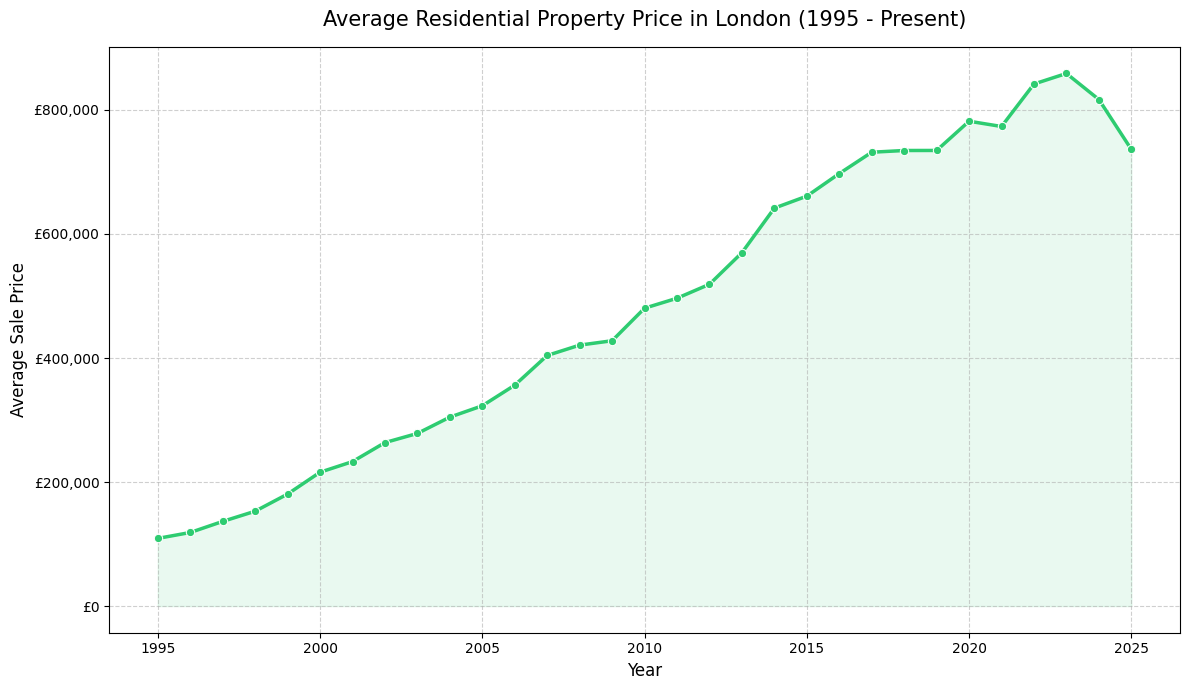

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 1. Ensure Date is in datetime format and extract the year
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

# 2. FILTER OUT 'OTHER': Keep only standard residential types
# D = Detached, S = Semi-Detached, T = Terraced, F = Flats
residential_types = ['D', 'S', 'T', 'F']
res_df = df[df['Type'].isin(residential_types)].copy()

# 3. Calculate average price per year using only residential data
yearly_prices = res_df.groupby('Year')['Price'].mean().reset_index()

# 4. Plotting
plt.figure(figsize=(12, 7))
ax = sns.lineplot(data=yearly_prices, x='Year', y='Price', marker='o', linewidth=2.5, color='#2ecc71')

# 5. Format Y-Axis with £ sign and commas
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))

# 6. Styling
plt.title('Average Residential Property Price in London (1995 - Present)', fontsize=15, pad=15)
plt.ylabel('Average Sale Price', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Adding a shaded area under the line for visual appeal
plt.fill_between(yearly_prices['Year'], yearly_prices['Price'], color='#2ecc71', alpha=0.1)

plt.tight_layout()
plt.savefig('london_residential_price_trend.png', dpi=300)
plt.show()

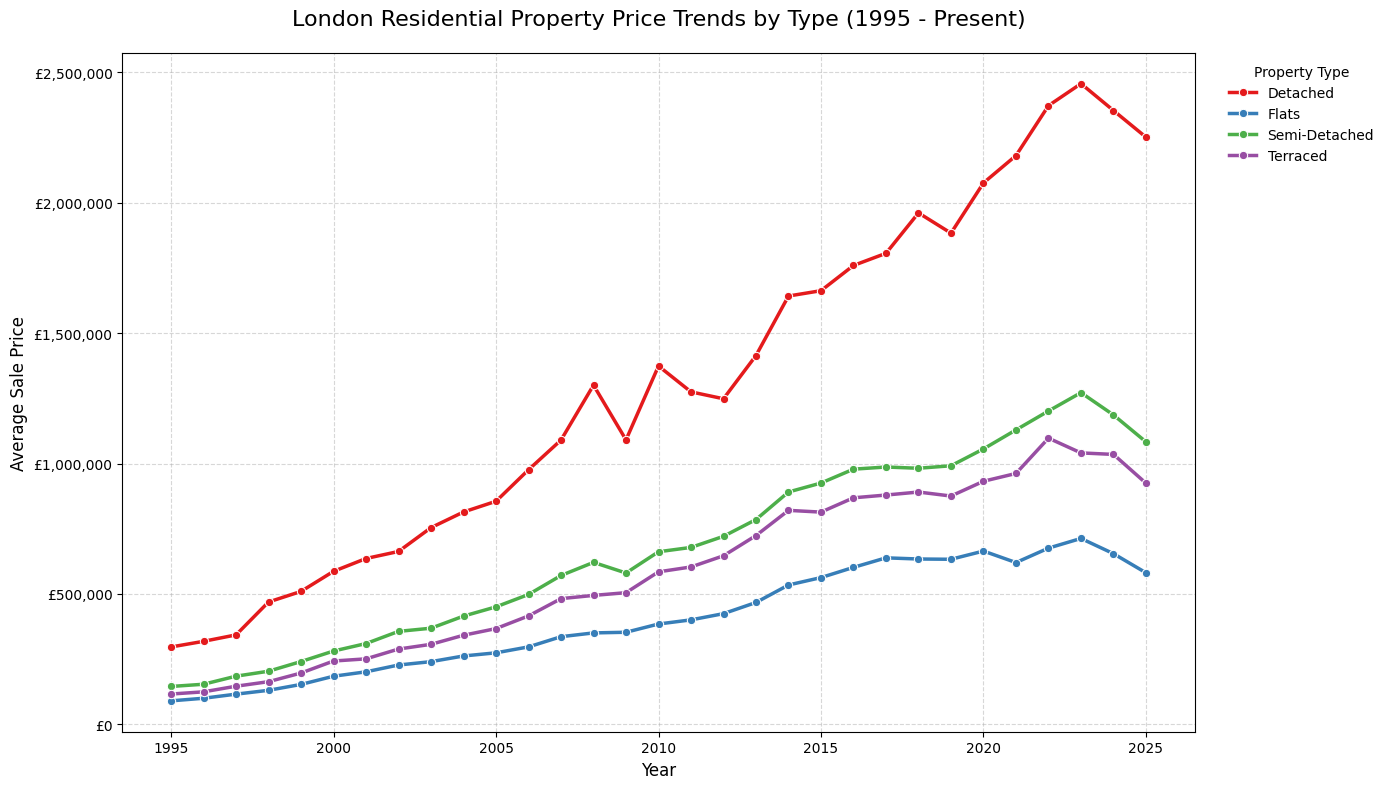

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 1. Setup Data: Extract Year and clean Tenure/Type
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

# 2. STRICT RESIDENTIAL FILTER: Exclude 'Other' (O)
# We filter here to ensure 'type_mapping' only applies to what we want
residential_types = ['D', 'S', 'T', 'F']
res_df = df[df['Type'].isin(residential_types)].copy()

# 3. Map the codes to full names
type_mapping = {'D': 'Detached', 'S': 'Semi-Detached', 'T': 'Terraced', 'F': 'Flats'}
res_df['Property Type'] = res_df['Type'].map(type_mapping)

# 4. Calculate average price per Year and Property Type
type_yearly_prices = res_df.groupby(['Year', 'Property Type'])['Price'].mean().reset_index()

# 5. Plotting
plt.figure(figsize=(14, 8))

# Use a specific palette like 'Set1' or 'husl' for distinct line colors
ax = sns.lineplot(
    data=type_yearly_prices, 
    x='Year', 
    y='Price', 
    hue='Property Type', 
    marker='o', 
    linewidth=2.5,
    palette='Set1'
)

# 6. Format Y-Axis with £ sign and commas
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))

# 7. Styling
plt.title('London Residential Property Price Trends by Type (1995 - Present)', fontsize=16, pad=20)
plt.ylabel('Average Sale Price', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Move legend outside so it doesn't block data points
plt.legend(title='Property Type', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('london_res_trends_by_type.png', dpi=300)
plt.show()

/var/folders/hg/m89r55wj5gndxf67bffsz28c0000gn/T/ipykernel_2286/3484705607.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


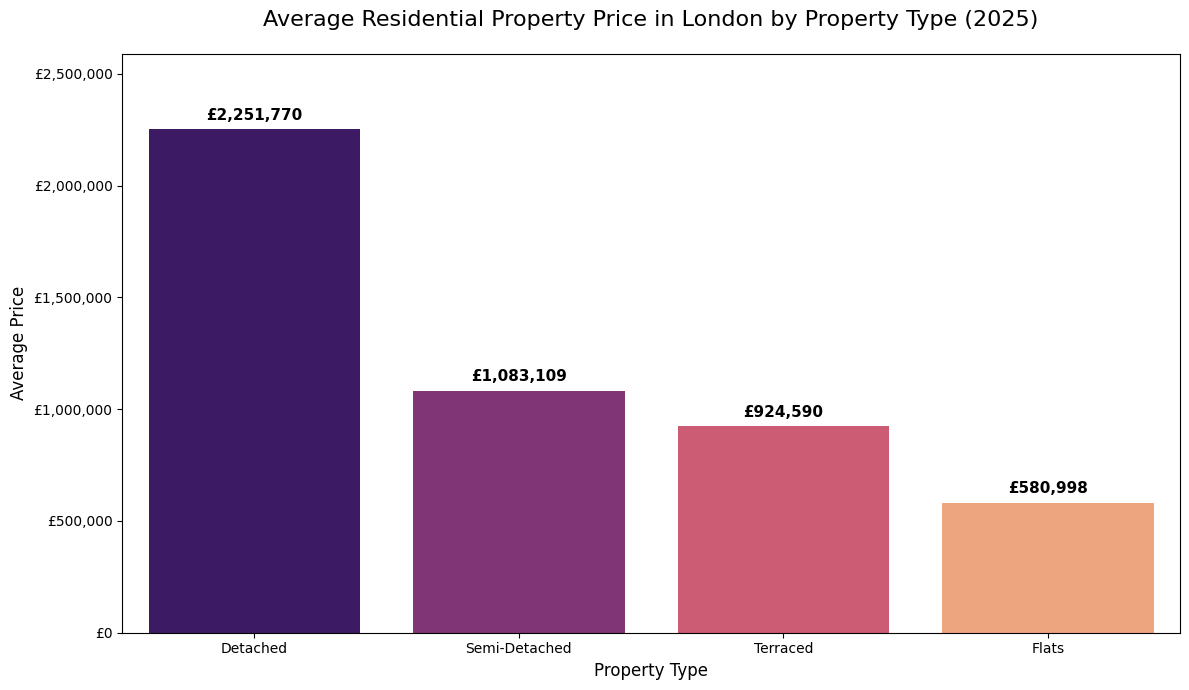

In [82]:
# 1. Setup Data: Get latest year and filter for residential only
df['Date'] = pd.to_datetime(df['Date'])
latest_year = df['Date'].dt.year.max()

# Filter for the most recent year AND only standard residential types
residential_types = ['D', 'S', 'T', 'F']
recent_res_df = df[(df['Date'].dt.year == latest_year) & 
                   (df['Type'].isin(residential_types))].copy()

# 2. Map the property types
type_mapping = {'D': 'Detached', 'S': 'Semi-Detached', 'T': 'Terraced', 'F': 'Flats'}

# 3. Calculate average and map names
type_prices = recent_res_df.groupby('Type')['Price'].mean().reset_index()
type_prices['Type'] = type_prices['Type'].map(type_mapping)

# 4. Sort strictly by price
type_prices = type_prices.sort_values(by='Price', ascending=False)

# 5. Plotting
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=type_prices, 
    x='Type', 
    y='Price', 
    palette='magma', 
    order=type_prices['Type']
)

# 6. Format Y-Axis with £ sign and commas
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))

# 7. Add labels on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'£{p.get_height():,.0f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

# 8. Styling
plt.title(f'Average Residential Property Price in London by Property Type ({latest_year})', fontsize=16, pad=20)
plt.ylabel('Average Price', fontsize=12)
plt.xlabel('Property Type', fontsize=12)
plt.ylim(0, type_prices['Price'].max() * 1.15)

plt.tight_layout()
plt.savefig('london_res_property_types_price_latest.png', dpi=300)
plt.show()

/var/folders/hg/m89r55wj5gndxf67bffsz28c0000gn/T/ipykernel_2286/2899025217.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_districts, x='Price', y='District', palette='magma')


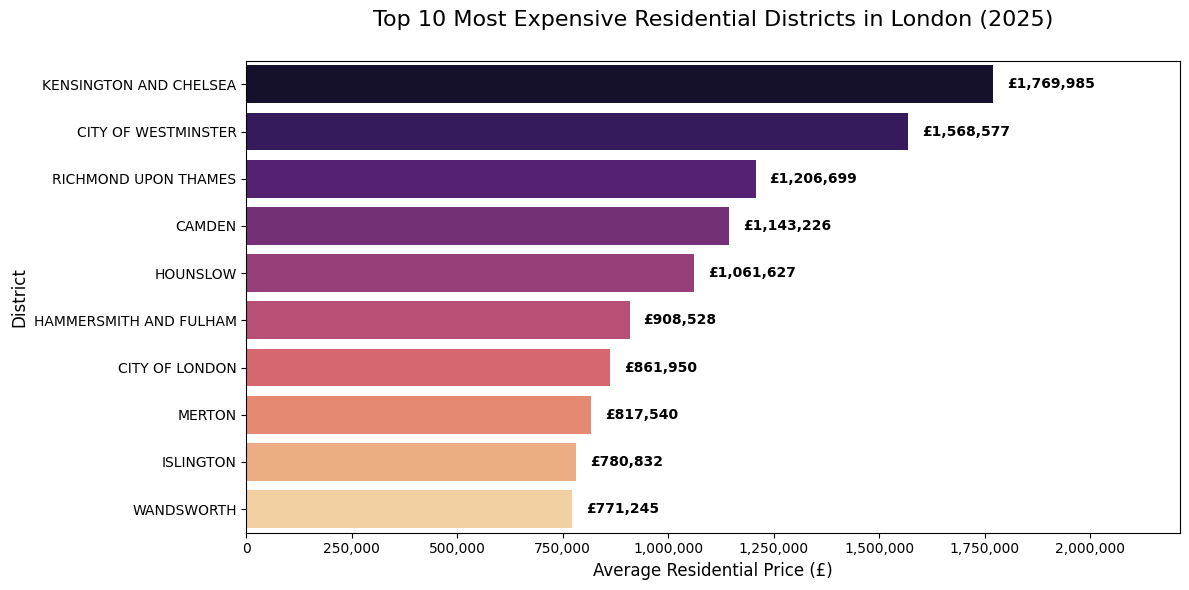

In [83]:
# 1. Setup Data: Get latest year and filter for residential only
df['Date'] = pd.to_datetime(df['Date'])
latest_year = df['Date'].dt.year.max()

# Filter for the most recent year AND only standard residential types (D, S, T, F)
residential_types = ['D', 'S', 'T', 'F']
res_df = df[(df['Date'].dt.year == latest_year) & 
                   (df['Type'].isin(residential_types))].copy()

# 2. Group by District and get the top 10
top_districts = res_df.groupby('District')['Price'].mean().sort_values(ascending=False).head(10).reset_index()

# 3. Plotting
plt.figure(figsize=(12, 6)) 
ax = sns.barplot(data=top_districts, x='Price', y='District', palette='magma')

# 4. Format X-Axis with £ sign and commas
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# 5. Add labels next to each bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'£{width:,.0f}', 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(10, 0),             
                textcoords='offset points',
                fontsize=10, fontweight='bold')

# 6. Final Styling
plt.title(f'Top 10 Most Expensive Residential Districts in London ({latest_year})', fontsize=16, pad=25)
plt.xlabel('Average Residential Price (£)', fontsize=12)
plt.ylabel('District', fontsize=12)

# Adjust x-axis limit to make room for the labels
plt.xlim(0, top_districts['Price'].max() * 1.25)

# 7. Save the chart
plt.tight_layout()
plt.savefig(f'top_10_residential_districts_{latest_year}.png', dpi=300)
plt.show()

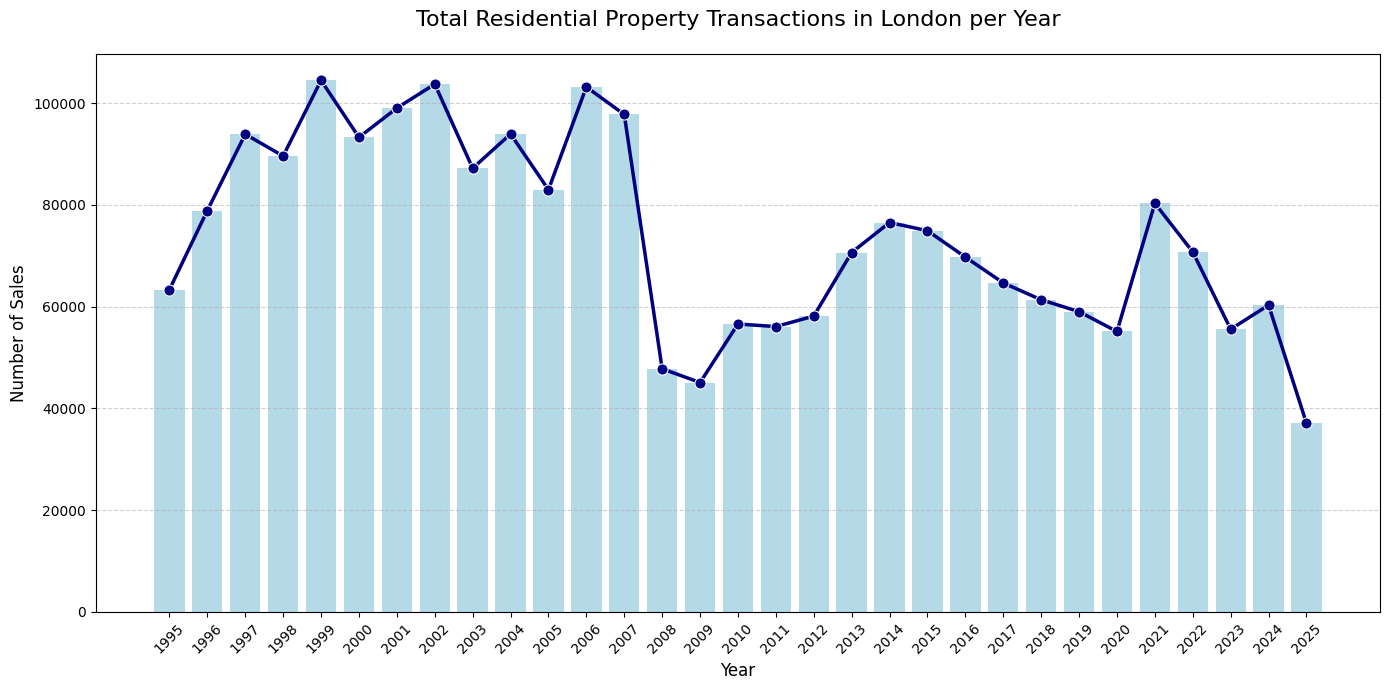

In [73]:
# 1. Filter for Residential Only
residential_types = ['D', 'S', 'T', 'F']
res_df = df[df['Type'].isin(residential_types)].copy()

# 2. Prepare Data (Residential Volume per Year)
sales_volume = res_df.groupby('Year').size().reset_index(name='Count')

# 3. Create Plot
plt.figure(figsize=(14, 7))

# Plot the bars (Volume)
sns.barplot(data=sales_volume, x='Year', y='Count', color='skyblue', alpha=0.7)

# Plot the line (Trend)
# Using range(len()) ensures the line connects the center of each bar correctly
sns.lineplot(data=sales_volume, x=range(len(sales_volume)), y='Count', 
             color='navy', marker='o', linewidth=2.5, markersize=8)

# 4. Formatting
plt.title('Total Residential Property Transactions in London per Year', fontsize=16, pad=20)
plt.xticks(rotation=45)
plt.ylabel('Number of Sales', fontsize=12)
plt.xlabel('Year', fontsize=12)

# Add a subtle grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 5. Save and Show
plt.tight_layout()
plt.savefig('london_residential_sales_volume.png', dpi=300)
plt.show()

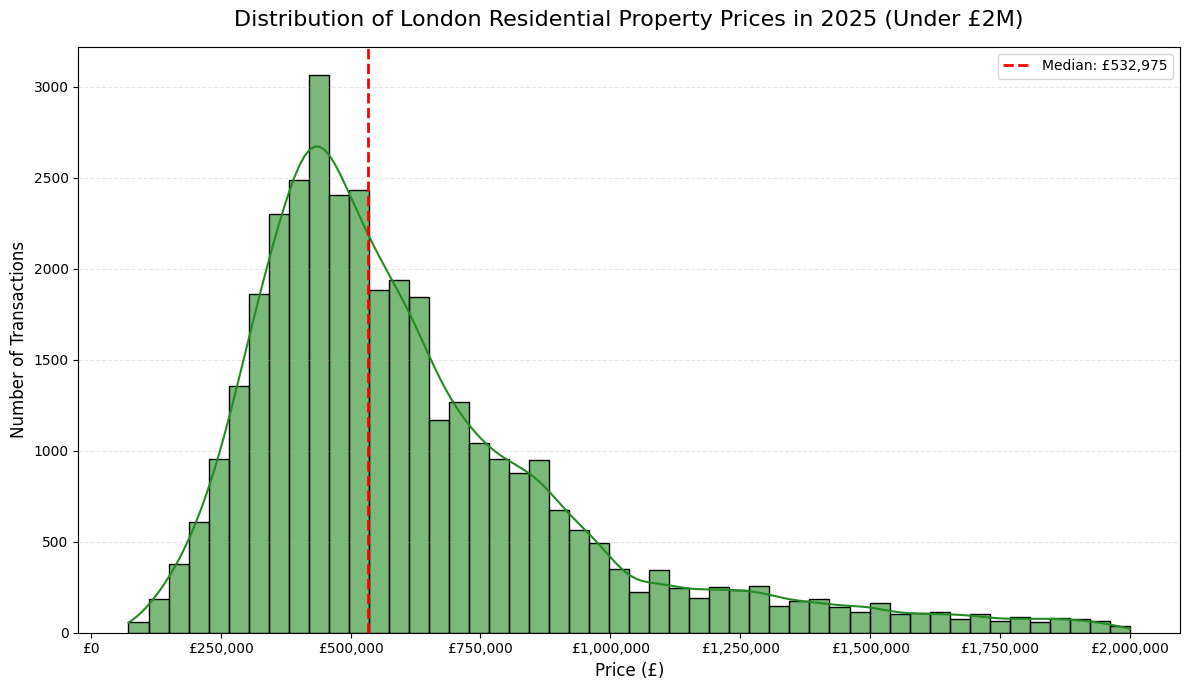

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 1. Ensure 'Year' exists and find the most recent year
df['Year'] = pd.to_datetime(df['Date']).dt.year
current_year = df['Year'].max() 

# 2. STRICT RESIDENTIAL FILTER: Latest year and types D, S, T, F
residential_types = ['D', 'S', 'T', 'F']
recent_res_df = df[(df['Year'] == current_year) & 
                   (df['Type'].isin(residential_types))].copy()

# 3. Apply the price cap for visualization clarity
# Most London transactions happen below £2M, focusing here avoids extreme outliers squashing the bins
filtered_prices = recent_res_df[recent_res_df['Price'] < 2000000]

# 4. Plotting
plt.figure(figsize=(12, 7))
sns.histplot(filtered_prices['Price'], bins=50, kde=True, color='forestgreen', alpha=0.6)

# 5. Format X-Axis with £ and commas
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))

# 6. Styling
plt.title(f'Distribution of London Residential Property Prices in {current_year} (Under £2M)', fontsize=16, pad=15)
plt.xlabel('Price (£)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 7. Add a vertical line for the Median Price
# The median is the most "honest" average for property prices
median_price = filtered_prices['Price'].median()
plt.axvline(median_price, color='red', linestyle='--', linewidth=2, label=f'Median: £{median_price:,.0f}')
plt.legend()

plt.tight_layout()
plt.savefig(f'residential_price_distribution_{current_year}.png', dpi=300)
plt.show()

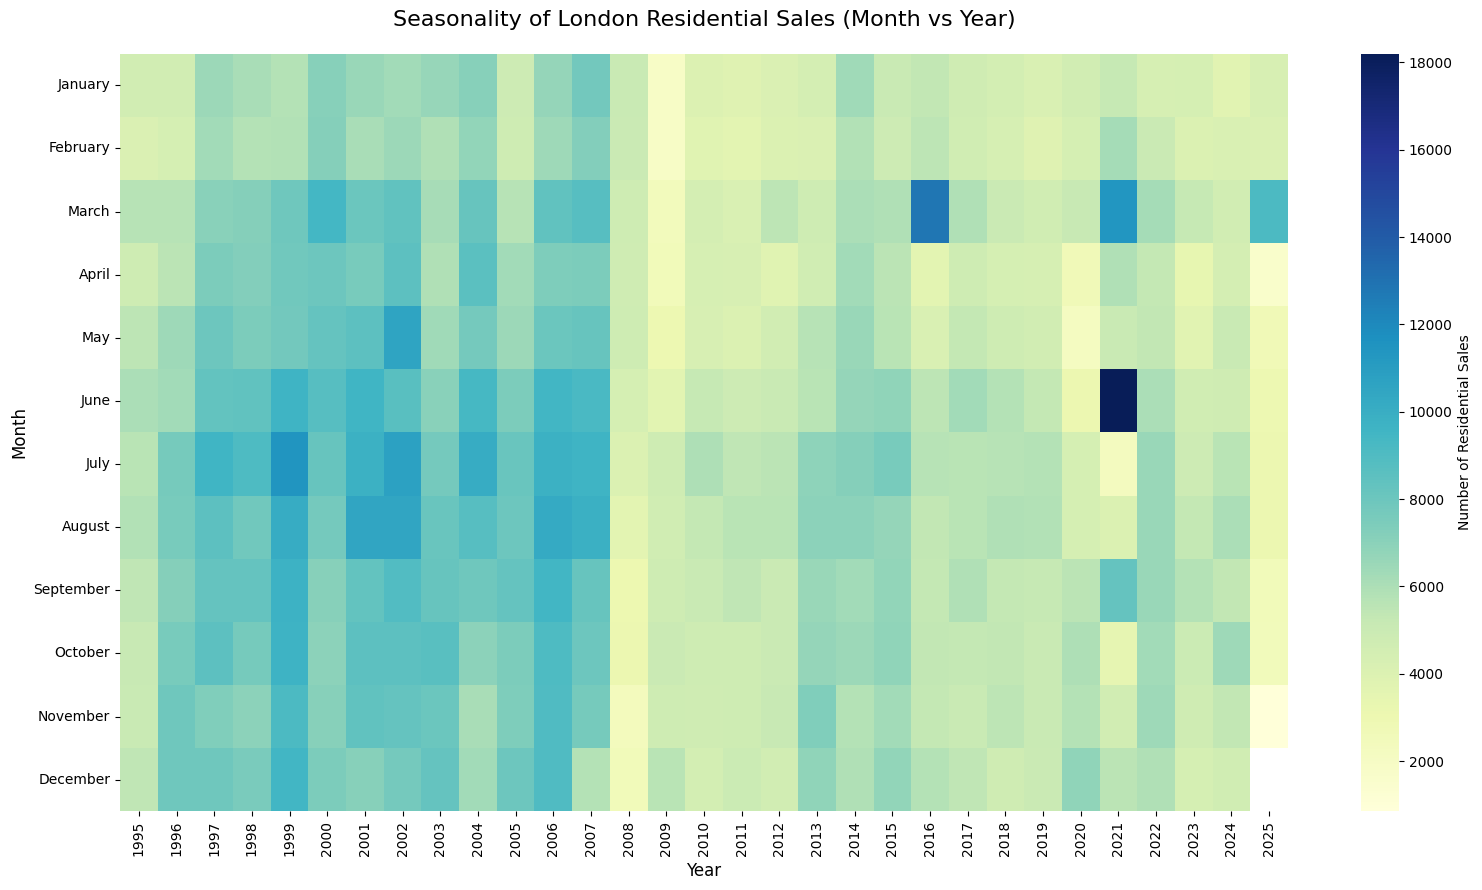

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# 1. Filter for Residential Only
residential_types = ['D', 'S', 'T', 'F']
res_df = df[df['Type'].isin(residential_types)].copy()

# 2. Extract Month and Year
res_df['Month'] = res_df['Date'].dt.month
res_df['Year'] = res_df['Date'].dt.year

# 3. Create pivot table of transaction counts
# Index=Month, Columns=Year
heatmap_data = res_df.pivot_table(index='Month', columns='Year', values='Price', aggfunc='count')

# 4. Convert Month index from numbers (1-12) to Names (Jan-Dec) for clarity
heatmap_data.index = [calendar.month_name[m] for m in heatmap_data.index]

# 5. Plotting
plt.figure(figsize=(16, 9))
sns.heatmap(
    heatmap_data, 
    cmap='YlGnBu', 
    annot=False, 
    cbar_kws={'label': 'Number of Residential Sales'}
)

# 6. Styling
plt.title('Seasonality of London Residential Sales (Month vs Year)', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Month', fontsize=12)

# 7. Save and Show
plt.tight_layout()
plt.savefig('london_residential_sales_heatmap.png', dpi=300)
plt.show()

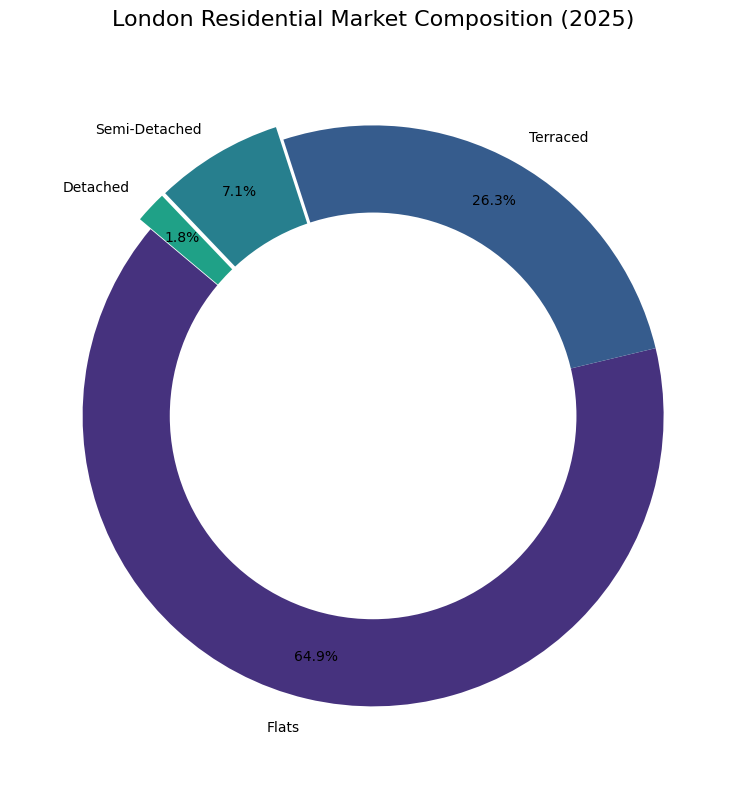

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure 'Year' exists and filter for the most recent year
df['Year'] = pd.to_datetime(df['Date']).dt.year
current_year = df['Year'].max()

# 2. Clean the 'Type' column and filter for Residential + Latest Year
df['Type'] = df['Type'].astype(str).str.strip()
res_types = ['D', 'S', 'T', 'F']
recent_res_df = df[(df['Type'].isin(res_types)) & (df['Year'] == current_year)].copy()

# 3. Get counts and map names
type_counts = recent_res_df['Type'].value_counts()
type_mapping = {'D': 'Detached', 'S': 'Semi-Detached', 'T': 'Terraced', 'F': 'Flats'}
type_counts.index = type_counts.index.map(type_mapping)

# 4. Final check: remove any index that didn't map
type_counts = type_counts[type_counts.index.notnull()]

# 5. Plotting
plt.figure(figsize=(10, 8))
# We add "explode" to slightly separate the smallest slice for better visibility
explode = [0.05 if i < 0.1 else 0 for i in (type_counts / type_counts.sum())]

plt.pie(
    type_counts, 
    labels=type_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('viridis'),
    pctdistance=0.85,
    explode=explode
)

# Draw the donut hole
centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title(f'London Residential Market Composition ({current_year})', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig(f'london_market_composition_{current_year}.png', dpi=300)
plt.show()

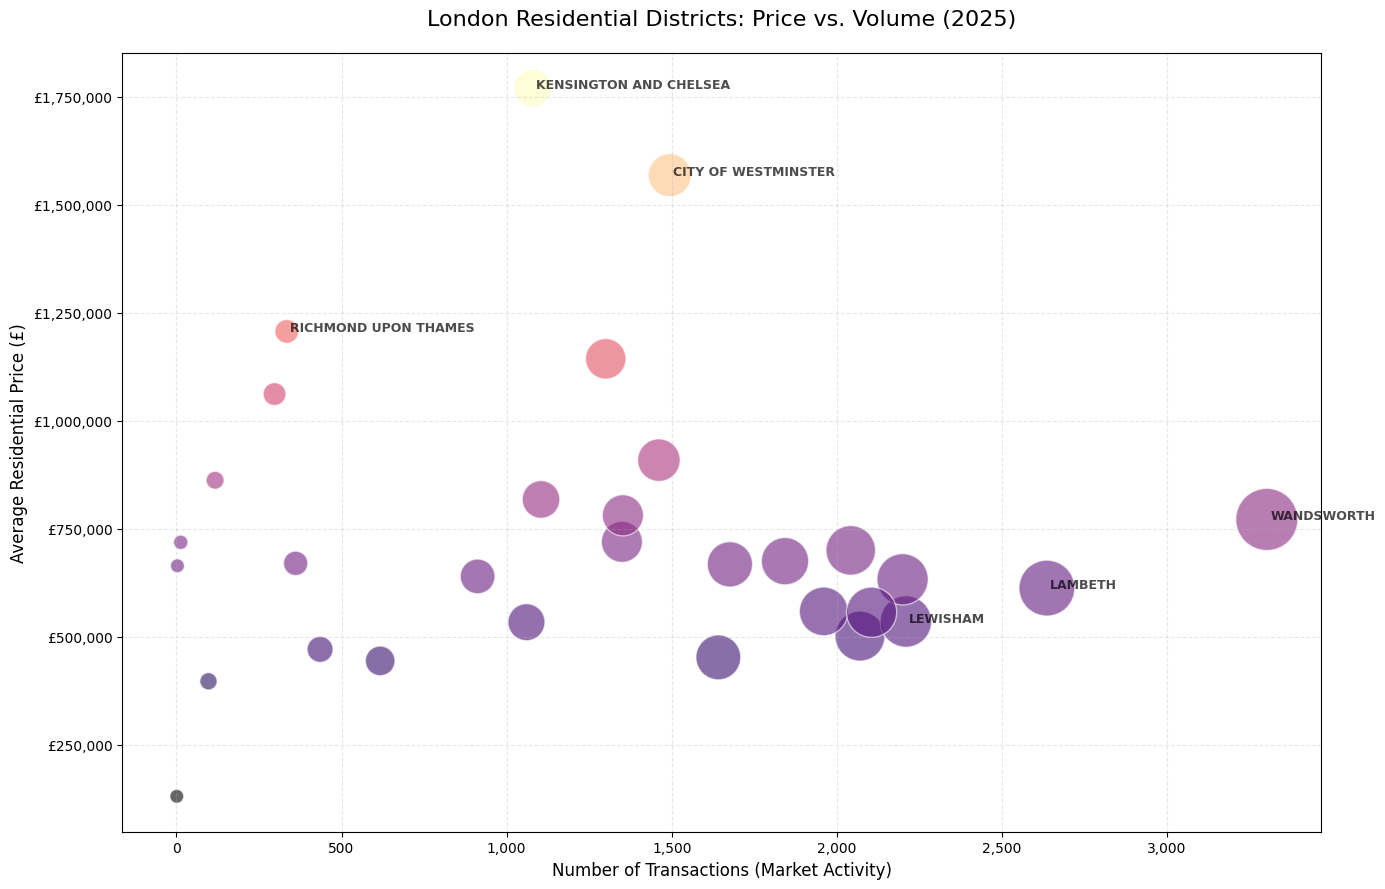

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 1. Setup Data: Get latest year and filter for residential only
df['Year'] = pd.to_datetime(df['Date']).dt.year
current_year = df['Year'].max()

residential_types = ['D', 'S', 'T', 'F']
res_df = df[(df['Year'] == current_year) & (df['Type'].isin(residential_types))].copy()

# 2. Group by District for Price and Count
stats = res_df.groupby('District').agg({'Price': 'mean', 'Type': 'count'}).reset_index()
stats.columns = ['District', 'Avg_Price', 'Sales_Count']

# 3. Plotting
plt.figure(figsize=(14, 9))
# Using a bubble chart (size based on Sales_Count)
ax = sns.scatterplot(
    data=stats, 
    x='Sales_Count', 
    y='Avg_Price', 
    size='Sales_Count', 
    sizes=(100, 2000), 
    alpha=0.6, 
    hue='Avg_Price', 
    palette='magma',
    legend=False # Legend is often messy with bubble sizes
)

# 4. Format Axes
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# 5. Add Labels for Outliers (The most interesting districts)
# We label districts that are either very expensive or have very high volume
for i in range(stats.shape[0]):
    if stats.Avg_Price[i] > stats.Avg_Price.quantile(0.9) or stats.Sales_Count[i] > stats.Sales_Count.quantile(0.9):
        plt.text(
            stats.Sales_Count[i]+10, stats.Avg_Price[i], 
            stats.District[i], 
            fontsize=9, weight='bold', alpha=0.7
        )

# 6. Styling
plt.title(f'London Residential Districts: Price vs. Volume ({current_year})', fontsize=16, pad=20)
plt.xlabel('Number of Transactions (Market Activity)', fontsize=12)
plt.ylabel('Average Residential Price (£)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f'residential_district_bubble_{current_year}.png', dpi=300)
plt.show()

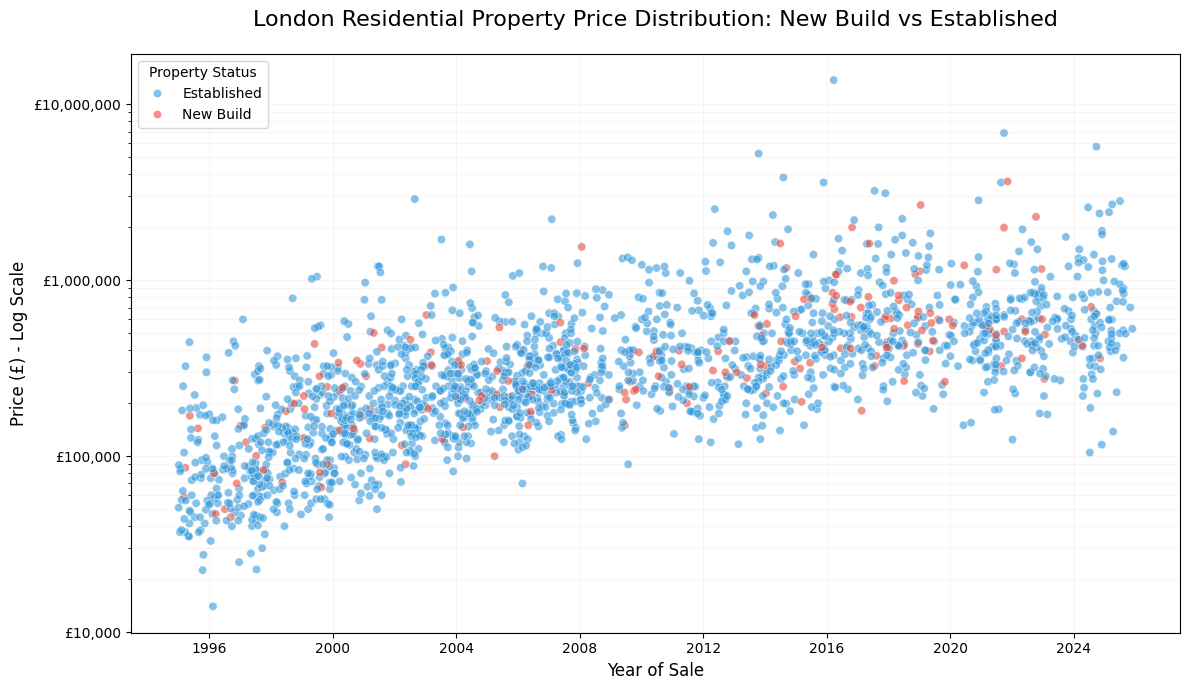

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 1. Setup Data: Extract Year and clean filters
df['Date'] = pd.to_datetime(df['Date'])

# 2. STRICT RESIDENTIAL FILTER: Keep only D, S, T, F
residential_types = ['D', 'S', 'T', 'F']
res_df = df[df['Type'].isin(residential_types)].copy()

# 3. Map New_Build status to readable labels
res_df['Property Status'] = res_df['New_Build'].map({'Y': 'New Build', 'N': 'Established'})

# 4. Filter out any potential NaNs in the status column
plot_df = res_df.dropna(subset=['Property Status'])

# 5. Sample the data (2000 points) for readability
# Use a random_state to ensure the "random" sample stays the same if you rerun it
sample_df = plot_df.sample(min(2000, len(plot_df)), random_state=42)

# 6. Create the Plot
plt.figure(figsize=(12, 7))
ax = sns.scatterplot(
    data=sample_df, 
    x='Date', 
    y='Price', 
    hue='Property Status', 
    alpha=0.6,
    palette={'New Build': '#e74c3c', 'Established': '#3498db'}
)

# 7. Format the axes
plt.yscale('log') # Log scale is vital for London's wide price range
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))

# 8. Styling
plt.title('London Residential Property Price Distribution: New Build vs Established', fontsize=16, pad=20)
plt.xlabel('Year of Sale', fontsize=12)
plt.ylabel('Price (£) - Log Scale', fontsize=12)
plt.legend(title='Property Status', loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.1)

# 9. Save and Show
plt.tight_layout()
plt.savefig('residential_new_vs_established_scatter.png', dpi=300)
plt.show()

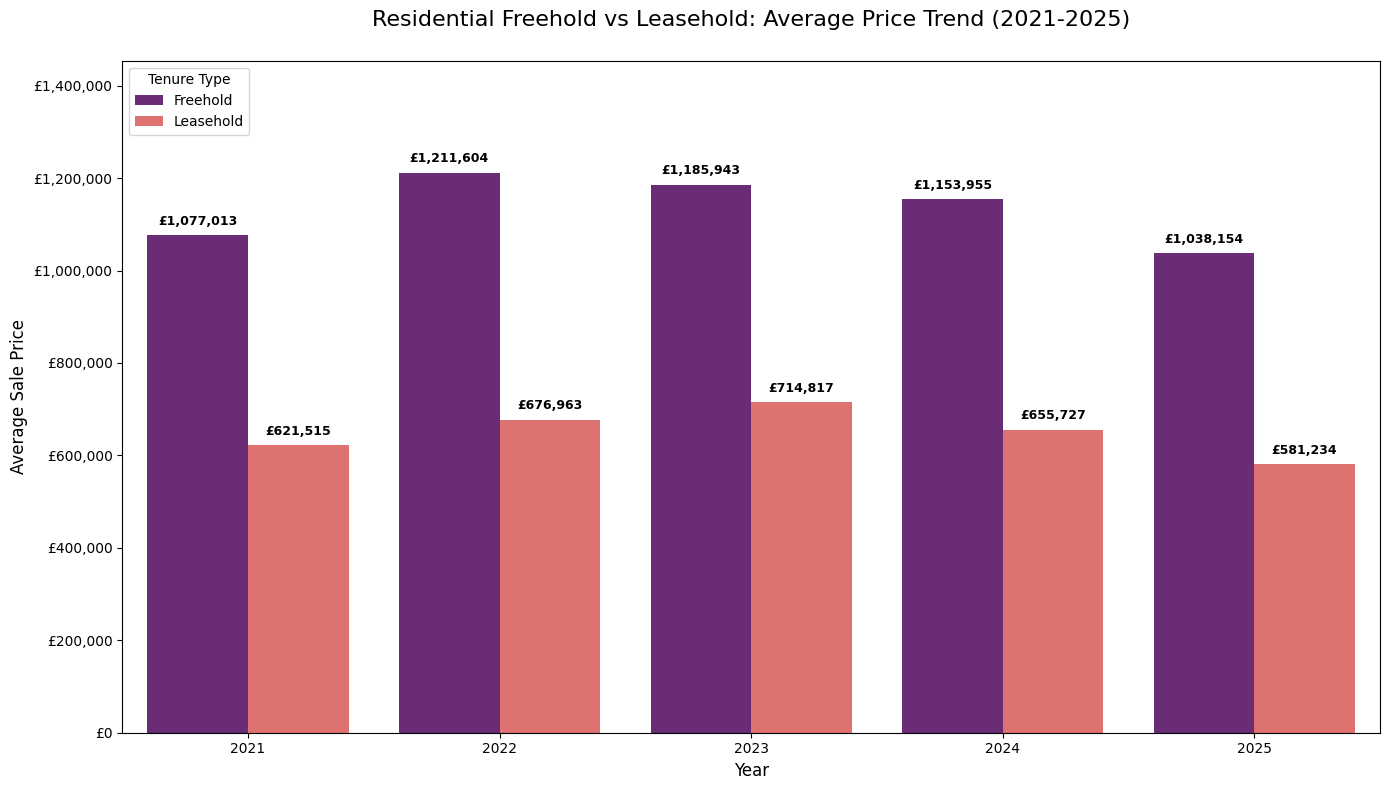

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 1. Prepare Year column and determine the last 5 years
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
latest_year = df['Year'].max()
start_year = latest_year - 4 

# 2. STRICT RESIDENTIAL FILTER: Focus on D, S, T, F and Tenure L, F
residential_types = ['D', 'S', 'T', 'F']
res_period_df = df[
    (df['Year'] >= start_year) & 
    (df['Tenure'].isin(['L', 'F'])) & 
    (df['Type'].isin(residential_types))
].copy()

# 3. Map Tenure codes to full names
tenure_mapping = {'L': 'Leasehold', 'F': 'Freehold'}
res_period_df['Tenure'] = res_period_df['Tenure'].map(tenure_mapping)

# 4. Group by Year and Tenure to get average residential prices
tenure_trend = res_period_df.groupby(['Year', 'Tenure'])['Price'].mean().reset_index()

# 5. Plotting (Grouped Bar Chart)
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=tenure_trend, 
    x='Year', 
    y='Price', 
    hue='Tenure', 
    palette='magma'
)

# 6. Format Y-Axis with £ sign and commas
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))

# 7. Add labels on top of each bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'£{p.get_height():,.0f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=9, fontweight='bold',
                    rotation=0)

# 8. Styling
plt.title(f'Residential Freehold vs Leasehold: Average Price Trend ({start_year}-{latest_year})', fontsize=16, pad=25)
plt.ylabel('Average Sale Price', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(title='Tenure Type', loc='upper left')

# Adjust y-axis limit to give space for the labels
plt.ylim(0, tenure_trend['Price'].max() * 1.2)

plt.tight_layout()
plt.savefig('residential_tenure_yearly_trend.png', dpi=300)
plt.show()

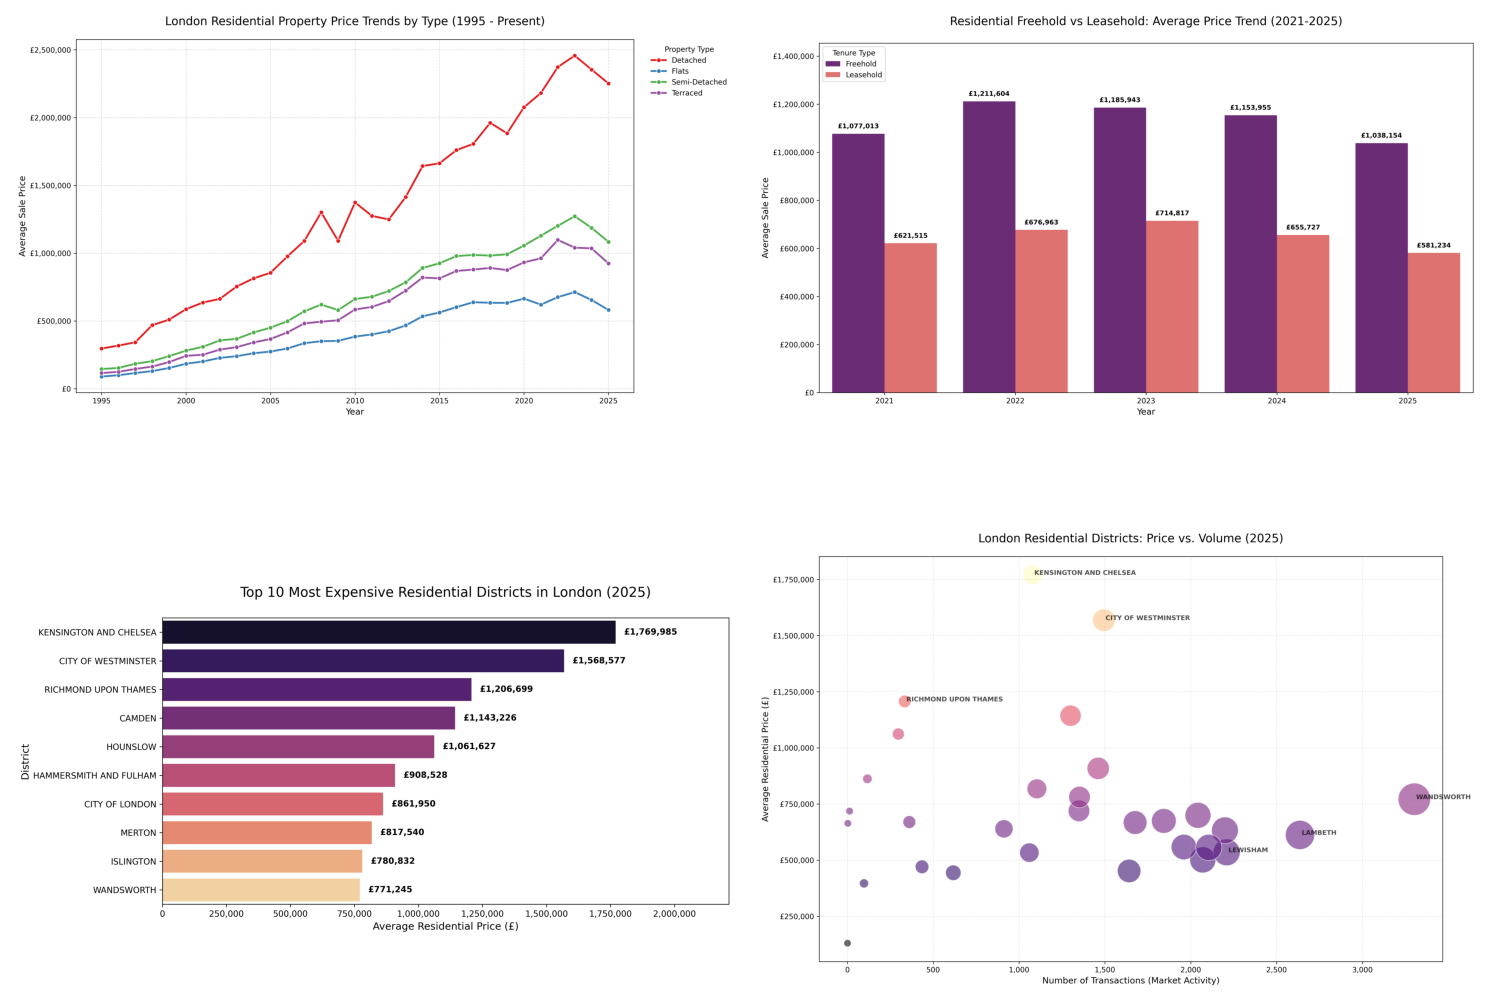

In [85]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# List of your image filenames
image_files = [
    'london_res_trends_by_type.png',
    'residential_tenure_yearly_trend.png',
    'top_10_residential_districts_2025.png',
    'residential_district_bubble_2025.png'
]

# Create a figure with a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, img_path in enumerate(image_files):
    try:
        # Load the image
        img = mpimg.imread(img_path)
        
        # Display the image on the corresponding subplot
        axes[i].imshow(img)
        
        # Remove axes for a clean dashboard look
        axes[i].axis('off')
        
        # Optional: Set a title based on the filename (cleaning up underscores)
        #title = img_path.replace('.png', '').replace('_', ' ').title()
        #axes[i].set_title(title, fontsize=12, pad=10)
        
    except FileNotFoundError:
        axes[i].text(0.5, 0.5, f'File Not Found:\n{img_path}', 
                     ha='center', va='center', color='red')
        axes[i].axis('off')

# Adjust layout to prevent overlapping
plt.tight_layout()

# Save the dashboard
plt.savefig('residential_dashboard_1.png', dpi=300, bbox_inches='tight')

# Display the result
plt.show()

Dashboard created successfully: london_sales_analysis_dashboard_2025.png


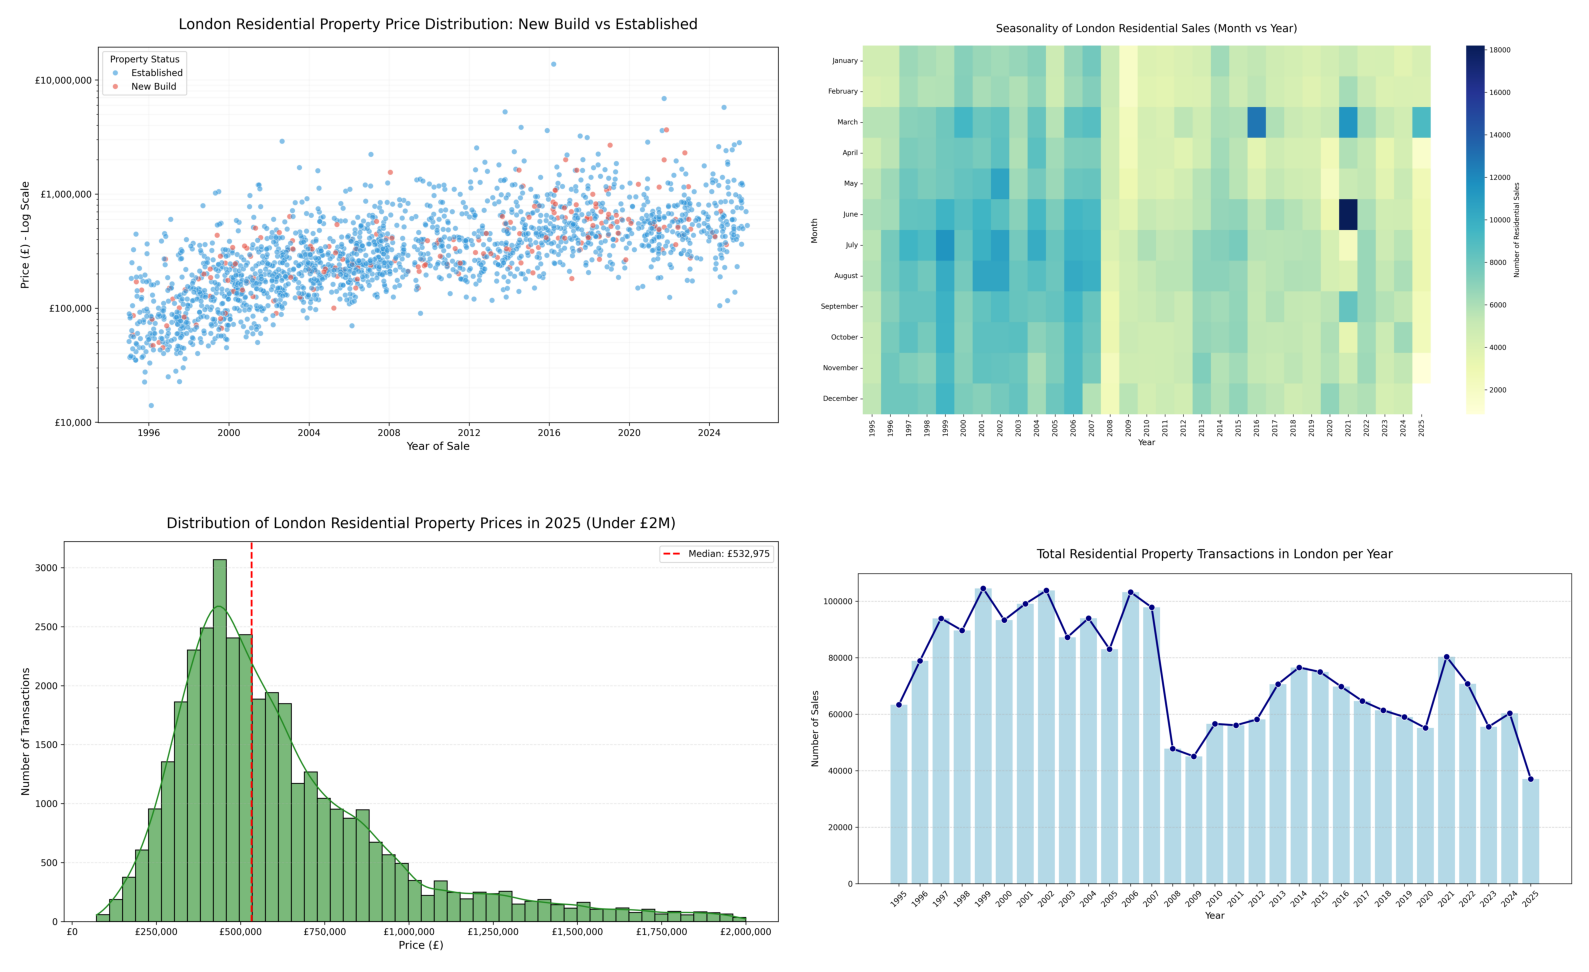

In [87]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# List of the new image filenames
image_files = [
    'residential_new_vs_established_scatter.png',
    'london_residential_sales_heatmap.png',
    'residential_price_distribution_2025.png',
    'london_residential_sales_volume.png'
]

# Create a figure with a 2x2 grid
# figsize is set to 16x12 to ensure high-quality visibility of details
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Add a main title to the entire dashboard
#fig.suptitle('London Residential Sales Analysis Dashboard', fontsize=22, fontweight='bold', y=0.98)

# Flatten the 2x2 axes array into a 1D array for easier looping
axes = axes.flatten()

for i, img_path in enumerate(image_files):
    try:
        # Load and display the image
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        
        # Remove the axes (ticks and borders)
        axes[i].axis('off')
        
        # Create a clean title from the filename
        # e.g., 'london_residential_sales_volume' -> 'London Residential Sales Volume'
        #clean_title = img_path.replace('.png', '').replace('_', ' ').title()
        #axes[i].set_title(clean_title, fontsize=14, pad=15)
        
    except FileNotFoundError:
        # Placeholder if an image is missing
        axes[i].text(0.5, 0.5, f'Missing Image:\n{img_path}', 
                     ha='center', va='center', color='gray', fontsize=12)
        axes[i].axis('off')

# Adjust the subplots to make room for titles and the main header
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save the final dashboard as a high-resolution PNG
plt.savefig('london_sales_analysis_dashboard.png', dpi=300, bbox_inches='tight')

print("Dashboard created successfully: london_sales_analysis_dashboard_2025.png")
plt.show()